# SARIMA - Seasonal Air Passenger Forecasting

## Project Overview

This project extends ARIMA by explicitly modeling the **12-month seasonal pattern** in the AirPassengers dataset using **SARIMA**. The notebook covers seasonal decomposition, stationarity, seasonal differencing, ACF/PACF, an ARIMA baseline, SARIMA model selection, evaluation, residual diagnostics, confidence intervals, and future forecasting.


## 1. Import Required Libraries


In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error


## 2. Load Dataset


In [2]:
df = pd.read_csv("AirPassengers.csv")
print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (144, 2)


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


## 3. Prepare Time Series


In [3]:
df["Month"] = pd.to_datetime(df["Month"])
df = df.sort_values("Month").set_index("Month").asfreq("MS")
df.info()
display(df.head())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Freq: MS
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## 4. Explore Dataset


In [4]:
print("Date range:", df.index.min(), "to", df.index.max())
print("Number of observations:", len(df))
print("\nMissing values:")
print(df.isnull().sum())
print("\nSummary statistics:")
display(df.describe())


Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00
Number of observations: 144

Missing values:
Passengers    0
dtype: int64

Summary statistics:


,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


## 5. Time-Series Visualization


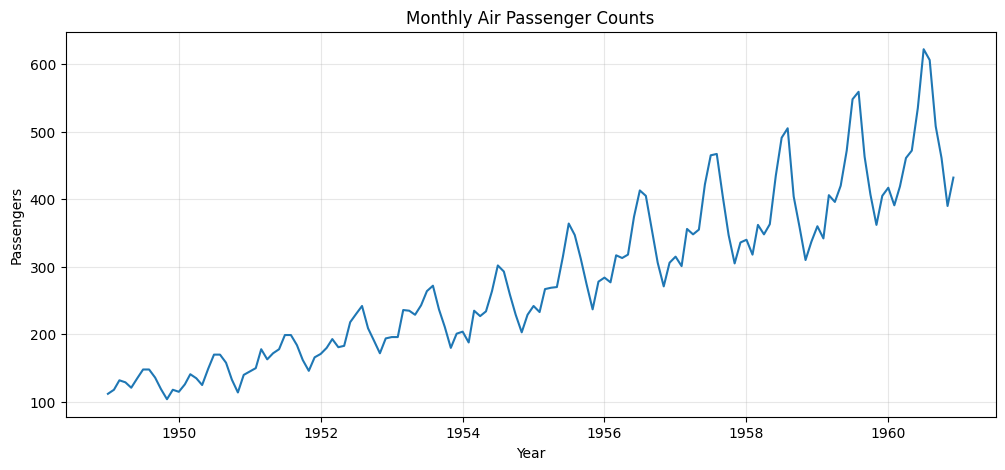

In [5]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Passengers"])
plt.title("Monthly Air Passenger Counts")
plt.xlabel("Year"); plt.ylabel("Passengers"); plt.grid(alpha=0.3); plt.show()


## 6. Seasonal Decomposition

A multiplicative decomposition is used because the seasonal fluctuations increase as the level of the series rises.


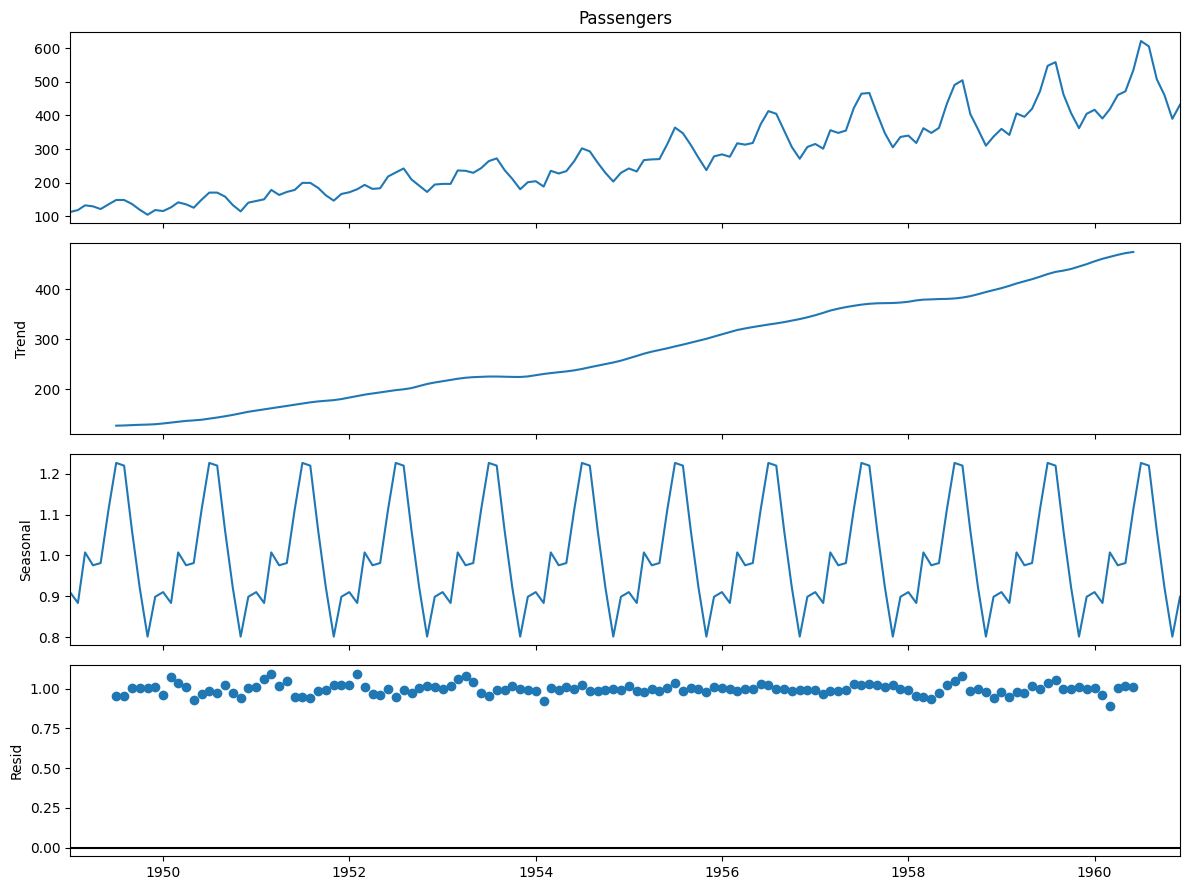

In [6]:
decomposition = seasonal_decompose(df["Passengers"], model="multiplicative", period=12)
fig = decomposition.plot()
fig.set_size_inches(12,9)
plt.tight_layout(); plt.show()


## 7. Stationarity Analysis

The Augmented Dickey-Fuller test evaluates whether the series is stationary. A p-value below 0.05 provides evidence against the null hypothesis of non-stationarity.


In [7]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"ADF Test - {name}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.6f}")
    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")
adf_test(df["Passengers"], "Original Series")


ADF Test - Original Series
ADF Statistic: 0.8154
p-value: 0.991880
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788


## 8. Seasonal Differencing


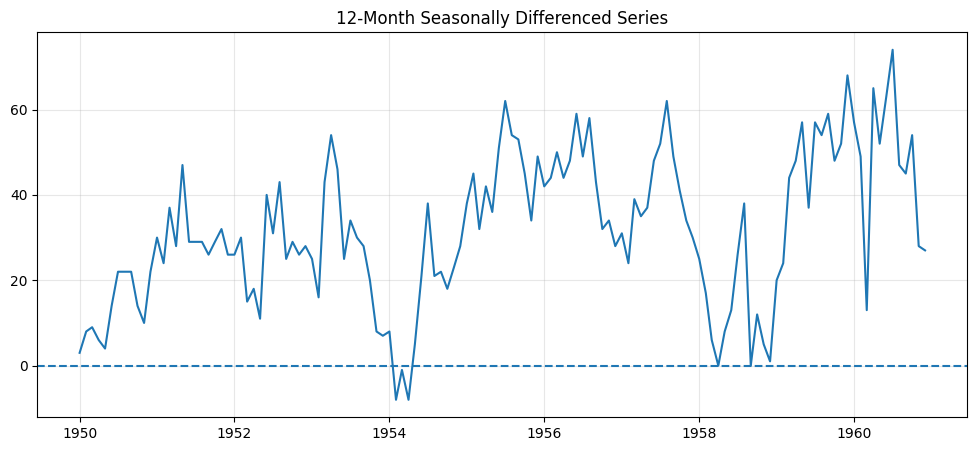

ADF Test - Seasonally Differenced Series
ADF Statistic: -3.3830
p-value: 0.011551
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788


In [8]:
df["Seasonal_Difference"] = df["Passengers"].diff(12)
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Seasonal_Difference"])
plt.axhline(0, linestyle="--")
plt.title("12-Month Seasonally Differenced Series")
plt.grid(alpha=0.3); plt.show()
adf_test(df["Seasonal_Difference"], "Seasonally Differenced Series")


## 9. ACF and PACF Analysis


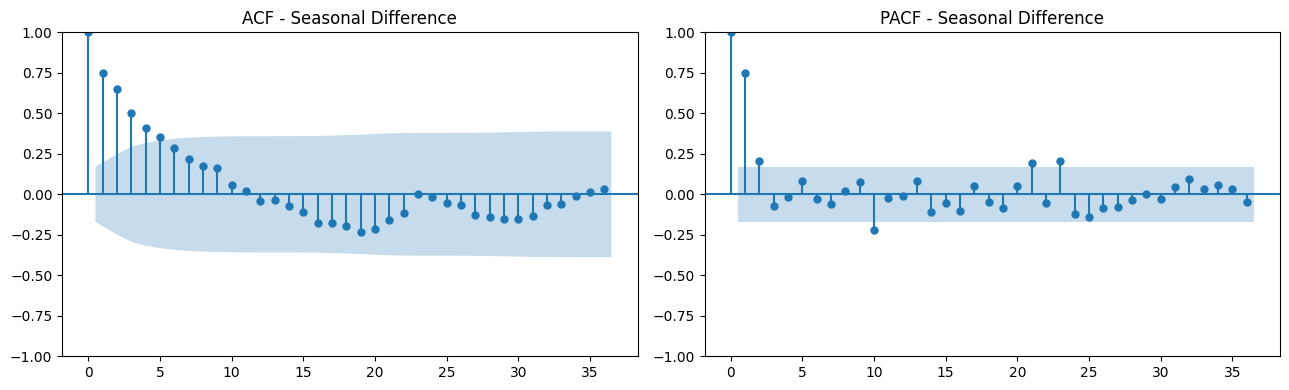

In [9]:
seasonal_diff = df["Seasonal_Difference"].dropna()
fig, axes = plt.subplots(1,2,figsize=(13,4))
plot_acf(seasonal_diff, lags=36, ax=axes[0])
plot_pacf(seasonal_diff, lags=36, method="ywm", ax=axes[1])
axes[0].set_title("ACF - Seasonal Difference")
axes[1].set_title("PACF - Seasonal Difference")
plt.tight_layout(); plt.show()


## 10. Chronological Train-Test Split


Training observations: 120
Testing observations: 24
Training period: 1949-01-01 00:00:00 to 1958-12-01 00:00:00
Testing period: 1959-01-01 00:00:00 to 1960-12-01 00:00:00


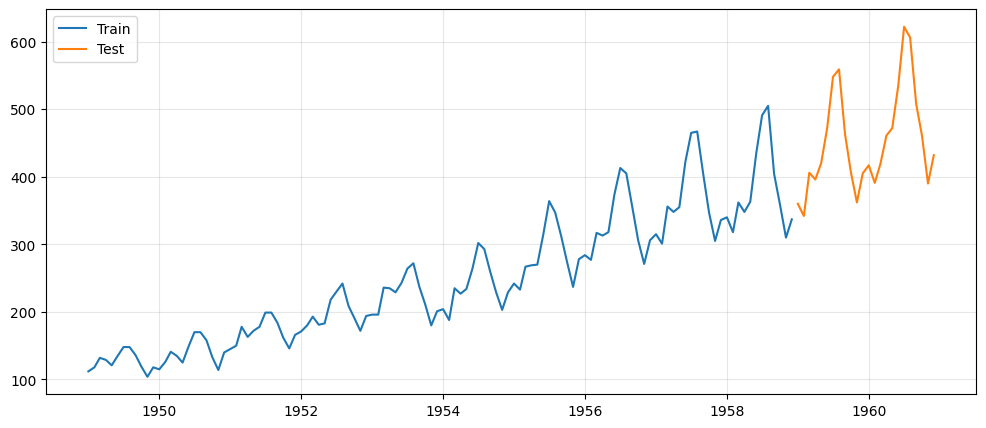

In [10]:
series = df["Passengers"].dropna()
train, test = series.iloc[:-24], series.iloc[-24:]
print("Training observations:", len(train))
print("Testing observations:", len(test))
print("Training period:", train.index.min(), "to", train.index.max())
print("Testing period:", test.index.min(), "to", test.index.max())
plt.figure(figsize=(12,5))
plt.plot(train,label="Train"); plt.plot(test,label="Test")
plt.legend(); plt.grid(alpha=0.3); plt.show()


## 11. ARIMA Baseline

ARIMA(2,1,2), selected in the preceding ARIMA project, is retained as the non-seasonal baseline.


In [11]:
arima_order=(2,1,2)
arima_fit=ARIMA(train,order=arima_order).fit()
arima_pred=arima_fit.forecast(steps=len(test)); arima_pred.index=test.index
arima_mae=mean_absolute_error(test,arima_pred)
arima_rmse=np.sqrt(mean_squared_error(test,arima_pred))
print(f"ARIMA{arima_order} MAE: {arima_mae:.3f}")
print(f"ARIMA{arima_order} RMSE: {arima_rmse:.3f}")


ARIMA(2, 1, 2) MAE: 69.105
ARIMA(2, 1, 2) RMSE: 90.703


## 12. SARIMA Model

SARIMA uses `(p,d,q)(P,D,Q,s)`, where the second group represents seasonal AR, differencing, MA, and seasonal period. For monthly data, `s=12`.


### 12.1 Compare SARIMA Candidates


In [12]:
candidate_models=[
((0,1,1),(0,1,1,12)),((1,1,0),(0,1,1,12)),
((1,1,1),(0,1,1,12)),((0,1,1),(1,1,0,12)),
((1,1,0),(1,1,0,12)),((1,1,1),(1,1,0,12)),
((0,1,1),(1,1,1,12)),((1,1,1),(1,1,1,12))]
results=[]
for order, seasonal_order in candidate_models:
    try:
        fitted=SARIMAX(train,order=order,seasonal_order=seasonal_order,
                       enforce_stationarity=False,enforce_invertibility=False).fit(disp=False)
        results.append({"Order":order,"Seasonal Order":seasonal_order,"AIC":fitted.aic})
    except Exception:
        pass
sarima_results=pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
display(sarima_results)
best_order=tuple(sarima_results.iloc[0]["Order"])
best_seasonal_order=tuple(sarima_results.iloc[0]["Seasonal Order"])
print("Selected order:",best_order)
print("Selected seasonal order:",best_seasonal_order)


,Order,Seasonal Order,AIC
0,"(0, 1, 1)","(0, 1, 1, 12)",707.508652
1,"(1, 1, 1)","(1, 1, 1, 12)",707.720135
2,"(1, 1, 1)","(0, 1, 1, 12)",708.438079
3,"(0, 1, 1)","(1, 1, 1, 12)",709.508259
4,"(1, 1, 0)","(1, 1, 0, 12)",714.718106
5,"(1, 1, 0)","(0, 1, 1, 12)",714.777395
6,"(1, 1, 1)","(1, 1, 0, 12)",716.035701
7,"(0, 1, 1)","(1, 1, 0, 12)",722.001245


Selected order: (0, 1, 1)
Selected seasonal order: (0, 1, 1, 12)


## 13. Train and Evaluate SARIMA


In [13]:
sarima_fit=SARIMAX(train,order=best_order,seasonal_order=best_seasonal_order,
    enforce_stationarity=False,enforce_invertibility=False).fit(disp=False)
sarima_forecast=sarima_fit.get_forecast(steps=len(test))
sarima_pred=sarima_forecast.predicted_mean; sarima_pred.index=test.index
sarima_mae=mean_absolute_error(test,sarima_pred)
sarima_rmse=np.sqrt(mean_squared_error(test,sarima_pred))
print(f"SARIMA{best_order}{best_seasonal_order} MAE: {sarima_mae:.3f}")
print(f"SARIMA{best_order}{best_seasonal_order} RMSE: {sarima_rmse:.3f}")


SARIMA(0, 1, 1)(0, 1, 1, 12) MAE: 66.275
SARIMA(0, 1, 1)(0, 1, 1, 12) RMSE: 71.829


## 14. ARIMA vs SARIMA Comparison


In [14]:
comparison_df=pd.DataFrame({
"Model":[f"ARIMA{arima_order}",f"SARIMA{best_order}{best_seasonal_order}"],
"MAE":[arima_mae,sarima_mae],"RMSE":[arima_rmse,sarima_rmse]})
display(comparison_df.sort_values("RMSE"))


,Model,MAE,RMSE
1,"SARIMA(0, 1, 1)(0, 1, 1, 12)",66.275341,71.829443
0,"ARIMA(2, 1, 2)",69.104612,90.702659


## 15. Actual vs Predicted Values


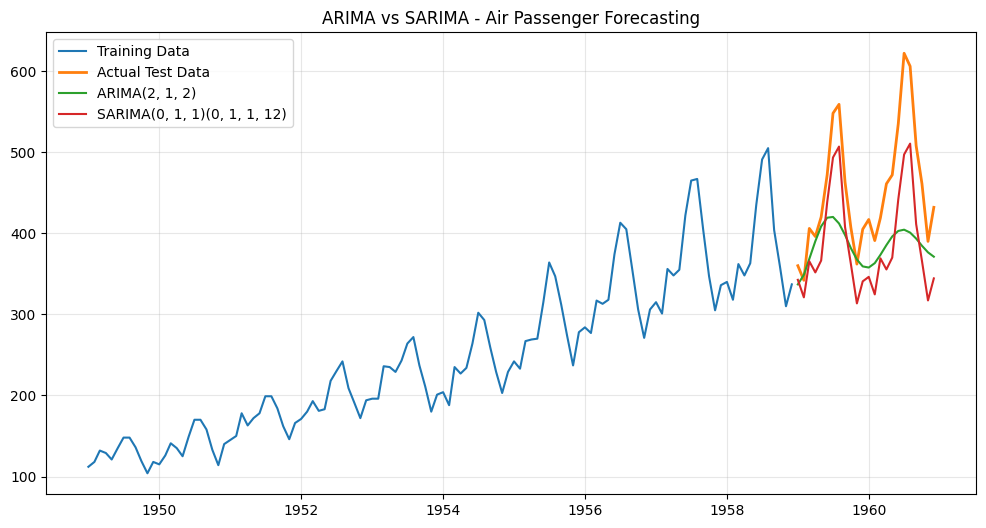

In [15]:
plt.figure(figsize=(12,6))
plt.plot(train,label="Training Data"); plt.plot(test,label="Actual Test Data",linewidth=2)
plt.plot(arima_pred,label=f"ARIMA{arima_order}")
plt.plot(sarima_pred,label=f"SARIMA{best_order}{best_seasonal_order}")
plt.title("ARIMA vs SARIMA - Air Passenger Forecasting")
plt.legend(); plt.grid(alpha=0.3); plt.show()


## 16. SARIMA Forecast Confidence Interval


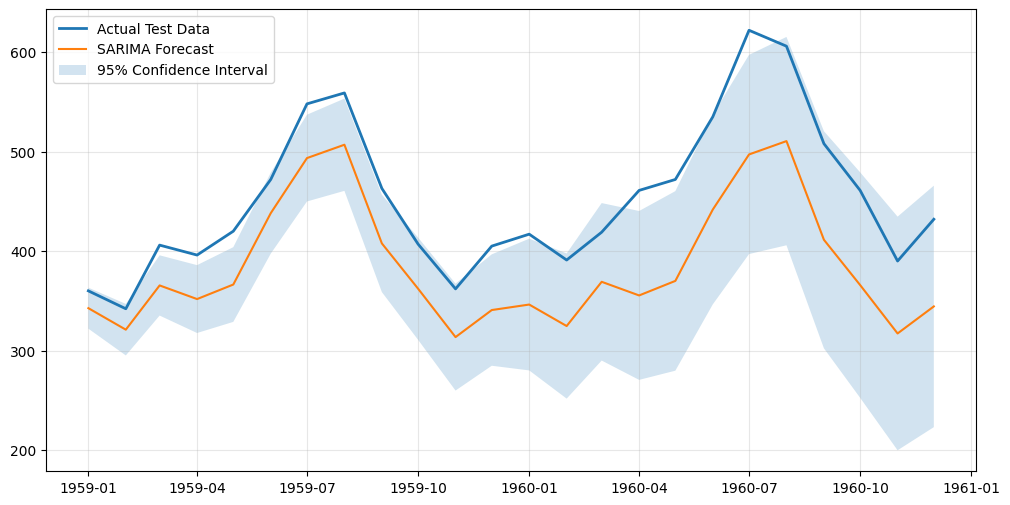

In [16]:
ci=sarima_forecast.conf_int(); ci.index=test.index
plt.figure(figsize=(12,6))
plt.plot(test,label="Actual Test Data",linewidth=2); plt.plot(sarima_pred,label="SARIMA Forecast")
plt.fill_between(test.index,ci.iloc[:,0],ci.iloc[:,1],alpha=0.2,label="95% Confidence Interval")
plt.legend(); plt.grid(alpha=0.3); plt.show()


## 17. Residual Diagnostics


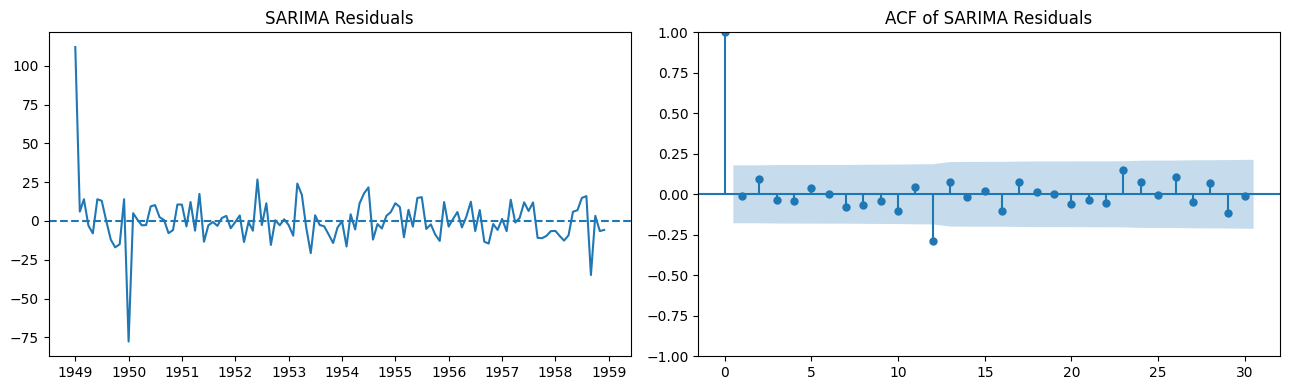

In [17]:
residuals=sarima_fit.resid
fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].plot(residuals); axes[0].axhline(0,linestyle="--"); axes[0].set_title("SARIMA Residuals")
plot_acf(residuals.dropna(),lags=30,ax=axes[1]); axes[1].set_title("ACF of SARIMA Residuals")
plt.tight_layout(); plt.show()


## 18. Future Forecasting


,Forecast,Lower 95%,Upper 95%
1961-01-01,447.190092,423.556723,470.823460
1961-02-01,422.050204,393.436669,450.663738
1961-03-01,453.852860,421.005750,486.699970
1961-04-01,489.973736,453.379598,526.567873
1961-05-01,502.308080,462.316466,542.299694
1961-06-01,564.316164,521.193925,607.438402
1961-07-01,649.810259,603.769780,695.850739
1961-08-01,636.860591,588.076126,685.645055
1961-09-01,539.078212,487.696092,590.460332
1961-10-01,491.190950,437.336326,545.045574


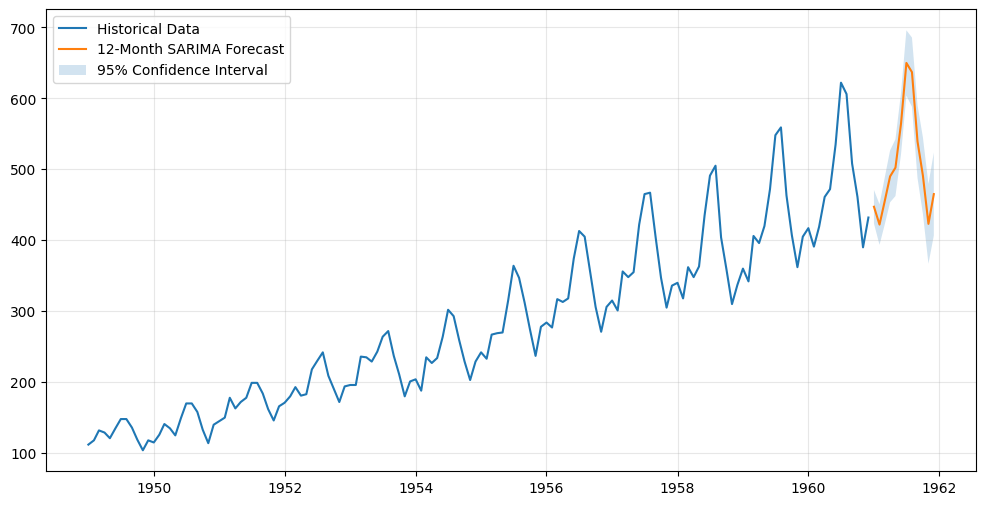

In [18]:
final_fit=SARIMAX(series,order=best_order,seasonal_order=best_seasonal_order,
    enforce_stationarity=False,enforce_invertibility=False).fit(disp=False)
future_result=final_fit.get_forecast(steps=12)
future_forecast=future_result.predicted_mean
future_ci=future_result.conf_int()
future_df=pd.DataFrame({"Forecast":future_forecast,"Lower 95%":future_ci.iloc[:,0],"Upper 95%":future_ci.iloc[:,1]})
display(future_df)
plt.figure(figsize=(12,6))
plt.plot(series,label="Historical Data"); plt.plot(future_forecast,label="12-Month SARIMA Forecast")
plt.fill_between(future_forecast.index,future_ci.iloc[:,0],future_ci.iloc[:,1],alpha=0.2,label="95% Confidence Interval")
plt.legend(); plt.grid(alpha=0.3); plt.show()


## 19. Key Findings

- The AirPassengers series contains a clear upward trend and strong **12-month seasonal structure**.
- The original series was non-stationary, with an ADF p-value of **0.991880**.
- Applying 12-month seasonal differencing reduced the ADF p-value to **0.011551**, providing evidence of stationarity at the 5% significance level.
- ACF and PACF analysis was used to inspect the remaining lag relationships after seasonal differencing.
- The non-seasonal ARIMA(2,1,2) baseline achieved an MAE of **69.105** and RMSE of **90.703**.
- Among the tested SARIMA candidates, **SARIMA(0,1,1)(0,1,1,12)** achieved the lowest AIC at approximately **707.509**.
- The selected SARIMA model achieved an MAE of **66.275** and RMSE of **71.829**.
- SARIMA improved both evaluation metrics compared with ARIMA, with the largest improvement occurring in RMSE.
- The results demonstrate the value of explicitly modeling seasonality when forecasting data with a strong recurring seasonal cycle.
- The final 12-month SARIMA forecast retains the yearly passenger pattern and includes 95% confidence intervals to represent forecast uncertainty.

## 20. Conclusion

This project demonstrated how **SARIMA extends ARIMA by explicitly modeling seasonal behavior** in time-series data.

The original AirPassengers series was strongly non-stationary. Applying 12-month seasonal differencing reduced the ADF p-value from **0.991880 to 0.011551**, providing evidence that the seasonally differenced series was stationary at the conventional 5% significance level.

The non-seasonal ARIMA(2,1,2) baseline achieved an MAE of **69.105** and RMSE of **90.703**. After comparing multiple seasonal specifications, **SARIMA(0,1,1)(0,1,1,12)** was selected and achieved an improved MAE of **66.275** and RMSE of **71.829**.

Overall, SARIMA provided better out-of-sample forecasting performance than the non-seasonal ARIMA baseline, particularly in RMSE. The results demonstrate that explicitly incorporating the 12-month seasonal cycle can improve forecasting for strongly seasonal monthly time-series data.